In [1]:
# =========================
# STEP 1: DATASET DETAILS
# =========================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# -------------------------
# 1. Load dataset
# -------------------------
file_path = "/content/drive/MyDrive/datamining/Dataset.csv"
df = pd.read_csv(file_path)

print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)

# -------------------------
# 2. Basic shape and columns
# -------------------------
print("\n[1] DATASET SHAPE")
print("Rows, Columns:", df.shape)

print("\n[2] COLUMN NAMES")
print(df.columns.tolist())

# -------------------------
# 3. Data types
# -------------------------
print("\n[3] DATA TYPES")
print(df.dtypes)

# -------------------------
# 4. First few rows
# -------------------------
print("\n[4] FIRST 5 ROWS")
print(df.head())

# -------------------------
# 5. Missing values
# -------------------------
print("\n[5] MISSING VALUES SUMMARY")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percent": missing_percent
}).sort_values(by="Missing_Percent", ascending=False)

print(missing_df)

# Only columns with missing values > 0
print("\n[5A] COLUMNS HAVING MISSING VALUES ONLY")
print(missing_df[missing_df["Missing_Count"] > 0])

# -------------------------
# 6. Duplicate rows
# -------------------------
print("\n[6] DUPLICATE ROWS")
print("Total duplicate rows:", df.duplicated().sum())

# -------------------------
# 7. Patient_ID check
# -------------------------
print("\n[7] PATIENT ID CHECK")
if "Patient_ID" in df.columns:
    print("Patient_ID column found.")
    print("Total unique patients:", df["Patient_ID"].nunique())

    patient_record_stats = df.groupby("Patient_ID").size().describe()
    print("\nPer-patient record count summary:")
    print(patient_record_stats)
else:
    print("Patient_ID column NOT found.")

# -------------------------
# 8. Target distribution
# -------------------------
print("\n[8] TARGET DISTRIBUTION")
if "SepsisLabel" in df.columns:
    print(df["SepsisLabel"].value_counts(dropna=False))
    print("\nTarget percentage:")
    print((df["SepsisLabel"].value_counts(normalize=True, dropna=False) * 100).round(2))
else:
    print("SepsisLabel column NOT found.")

# -------------------------
# 9. Numeric summary
# -------------------------
print("\n[9] NUMERIC FEATURES SUMMARY")
print(df.describe(include=[np.number]).T)

# -------------------------
# 10. Non-numeric summary
# -------------------------
print("\n[10] NON-NUMERIC FEATURES SUMMARY")
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) > 0:
    print(df[non_numeric_cols].describe().T)
else:
    print("No non-numeric columns found.")

# -------------------------
# 11. Missing values percentage > 50%
# -------------------------
print("\n[11] COLUMNS WITH >50% MISSING VALUES")
high_missing = missing_df[missing_df["Missing_Percent"] > 50]
print(high_missing if len(high_missing) > 0 else "No columns with >50% missing values.")

# -------------------------
# 12. Class imbalance check
# -------------------------
print("\n[12] CLASS IMBALANCE CHECK")
if "SepsisLabel" in df.columns:
    class_counts = df["SepsisLabel"].value_counts()
    if len(class_counts) == 2:
        minority_ratio = class_counts.min() / class_counts.max()
        print("Minority / Majority ratio:", round(minority_ratio, 4))
    else:
        print("Target does not have exactly 2 classes.")
else:
    print("SepsisLabel column NOT found.")

# -------------------------
# 13. Final quick summary
# -------------------------
print("\n" + "="*70)
print("FINAL QUICK SUMMARY")
print("="*70)
print(f"Total Rows                : {df.shape[0]}")
print(f"Total Columns             : {df.shape[1]}")
print(f"Total Missing Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Rows            : {df.duplicated().sum()}")

if "Patient_ID" in df.columns:
    print(f"Unique Patients           : {df['Patient_ID'].nunique()}")

if "SepsisLabel" in df.columns:
    print("SepsisLabel Distribution  :")
    print(df["SepsisLabel"].value_counts())

print("="*70)

Mounted at /content/drive
DATASET LOADED SUCCESSFULLY

[1] DATASET SHAPE
Rows, Columns: (546123, 44)

[2] COLUMN NAMES
['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

[3] DATA TYPES
Unnamed: 0            int64
Hour                  int64
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2       

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Model,Accuracy,Precision,Recall,F1-score,AUROC,AUPRC
0,Logistic Regression,0.741343,0.051408,0.621053,0.094956,0.742384,0.079915


,precision,recall,f1-score,support
0,0.988752,0.744030,0.849110,106329.000000
1,0.051408,0.621053,0.094956,2375.000000
accuracy,0.741343,0.741343,0.741343,0.741343
macro avg,0.520080,0.682541,0.472033,108704.000000
weighted avg,0.968272,0.741343,0.832633,108704.000000


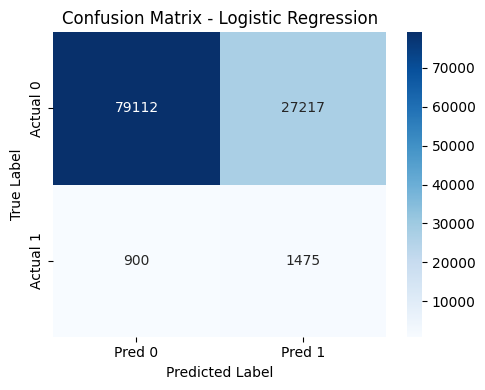

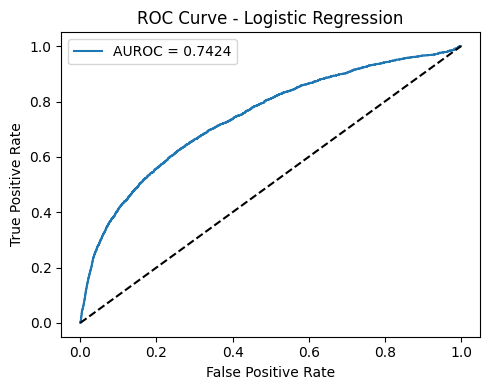

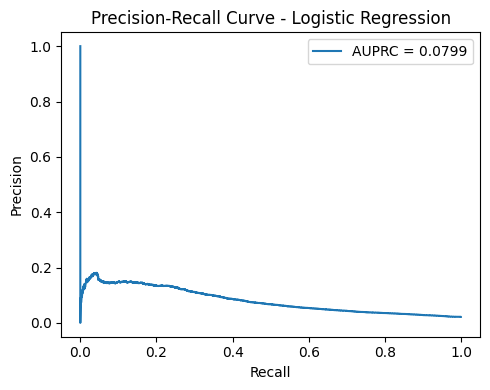

,Feature,Coefficient,Abs_Coefficient
23,ICULOS,0.491661,0.491661
20,Unit1,0.215340,0.215340
21,Unit2,-0.215340,0.215340
1,HR,0.207959,0.207959
7,Resp,0.180541,0.180541
3,Temp,0.177960,0.177960
22,HospAdmTime,-0.154699,0.154699
16,WBC,0.144284,0.144284
11,Creatinine,0.137577,0.137577
5,MAP,-0.123287,0.123287


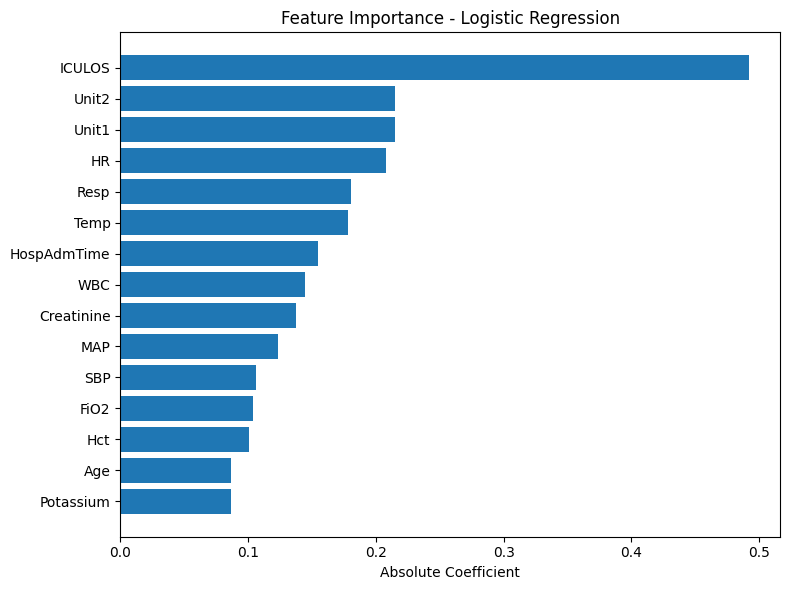


All outputs saved successfully in:
/content/drive/MyDrive/datamining/results/model_1_logistic_regression

Status marked as DONE.


In [3]:
# ==========================================
# MODEL 1: LOGISTIC REGRESSION
# SAVE EVERYTHING TO DRIVE + RESUME SUPPORT
# ==========================================

# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Imports
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

# 3) Paths
base_dir = "/content/drive/MyDrive/datamining"
data_path = os.path.join(base_dir, "Dataset.csv")
save_dir = os.path.join(base_dir, "results", "model_1_logistic_regression")
os.makedirs(save_dir, exist_ok=True)

status_file = os.path.join(save_dir, "status.txt")

# 4) Skip if already done
if os.path.exists(status_file):
    with open(status_file, "r") as f:
        status = f.read().strip()
    if status == "DONE":
        print("Model 1 already completed. Files are saved in Drive:")
        print(save_dir)
        raise SystemExit

# 5) Load dataset
df = pd.read_csv(data_path)

# 6) Basic cleaning
drop_cols = ["Unnamed: 0", "EtCO2"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df = df.dropna(subset=["SepsisLabel", "Patient_ID"])
df = df.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)

# 7) Drop very high missing columns (>90%), but keep some important clinical columns
missing_percent = df.isnull().mean() * 100
important_keep = ["Lactate", "Platelets", "Creatinine", "WBC"]
high_missing_cols = missing_percent[missing_percent > 90].index.tolist()
high_missing_cols = [
    c for c in high_missing_cols
    if c not in important_keep and c not in ["SepsisLabel", "Patient_ID", "Hour"]
]
df = df.drop(columns=high_missing_cols)

# Save dropped column info
pd.DataFrame({"dropped_columns": high_missing_cols}).to_csv(
    os.path.join(save_dir, "dropped_columns.csv"), index=False
)

# 8) Patient-wise forward fill
exclude_ffill = ["SepsisLabel", "Patient_ID", "Hour"]
ffill_cols = [c for c in df.columns if c not in exclude_ffill]
df[ffill_cols] = df.groupby("Patient_ID")[ffill_cols].ffill()

# 9) Feature/target split
target_col = "SepsisLabel"
group_col = "Patient_ID"
feature_cols = [c for c in df.columns if c not in [target_col, group_col]]

# 10) Patient-wise train-test split
patient_df = df[[group_col, target_col]].groupby(group_col)[target_col].max().reset_index()

train_patients, test_patients = train_test_split(
    patient_df,
    test_size=0.2,
    random_state=42,
    stratify=patient_df[target_col]
)

train_ids = set(train_patients[group_col])
test_ids = set(test_patients[group_col])

train_df = df[df[group_col].isin(train_ids)].copy()
test_df  = df[df[group_col].isin(test_ids)].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col].astype(int)

X_test = test_df[feature_cols]
y_test = test_df[target_col].astype(int)

# Save split info
split_info = {
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_patients": int(len(train_ids)),
    "test_patients": int(len(test_ids)),
    "n_features": int(len(feature_cols))
}
with open(os.path.join(save_dir, "split_info.json"), "w") as f:
    json.dump(split_info, f, indent=2)

# 11) Imputation
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# 12) Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Save preprocessing objects
joblib.dump(imputer, os.path.join(save_dir, "imputer.pkl"))
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

# 13) Train model
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Save model
joblib.dump(model, os.path.join(save_dir, "logistic_regression_model.pkl"))

# 14) Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 15) Metrics
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
f1    = f1_score(y_test, y_pred, zero_division=0)
auroc = roc_auc_score(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)

metrics_df = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1,
    "AUROC": auroc,
    "AUPRC": auprc
}])

display(metrics_df)
metrics_df.to_csv(os.path.join(save_dir, "metrics.csv"), index=False)

# 16) Classification report table
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv(os.path.join(save_dir, "classification_report.csv"))

# 17) Save predictions
pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_prob": y_prob
})
pred_df.to_csv(os.path.join(save_dir, "predictions.csv"), index=False)

# 18) Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 19) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "roc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 20) Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(recall_vals, precision_vals, label=f"AUPRC = {auprc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "pr_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 21) Coefficient-based feature importance
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_[0],
    "Abs_Coefficient": np.abs(model.coef_[0])
}).sort_values("Abs_Coefficient", ascending=False)

display(coef_df.head(20))
coef_df.to_csv(os.path.join(save_dir, "feature_importance.csv"), index=False)

plt.figure(figsize=(8,6))
top_coef = coef_df.head(15).sort_values("Abs_Coefficient", ascending=True)
plt.barh(top_coef["Feature"], top_coef["Abs_Coefficient"])
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "feature_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 22) Mark as done
with open(status_file, "w") as f:
    f.write("DONE")

print("\nAll outputs saved successfully in:")
print(save_dir)
print("\nStatus marked as DONE.")